## 5 Вопрос
Дан сигнал x[n] = u[n]- u[n-4], где u[m] - единичный скачок  . В предположении, что дискретизация проводилась при выполнении условий теоремы Котельникова, напишите код, который рисует восстановленный непрерывный сигнал. Так как на компьютере доступна отрисовка только дискретных сигналов, допустить упрощение, что непрерывный сигнал — это дискретный сигнал с очень мелким шагом

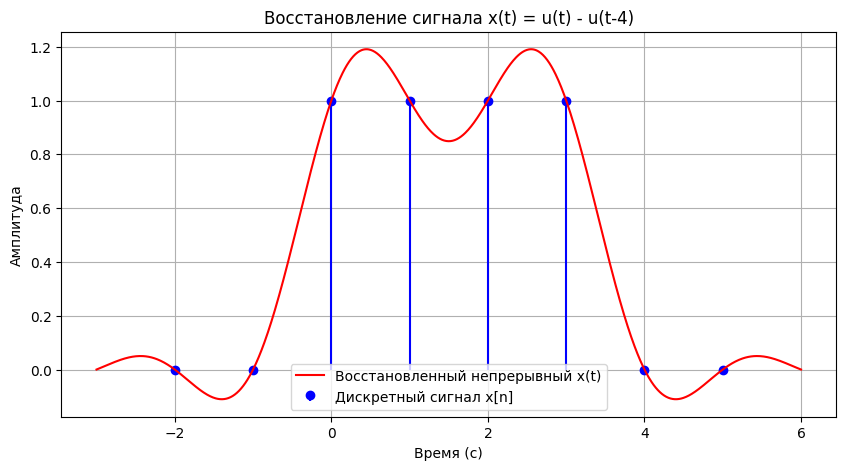

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры сигнала
fs = 1.0  # Частота дискретизации (Гц) - условно, шаг Δ = 1 с
n = np.arange(-2, 6)  # Дискретные отсчёты (n)
x_n = np.where((n >= 0) & (n < 4), 1, 0)  # x[n] = u[n] - u[n-4]

# Мелкая сетка для "непрерывного" времени
t_continuous = np.linspace(-3, 6, 1000)  # Шаг ~0.008 с

# Восстановление сигнала по формуле Уиттекера-Шеннона
x_t = np.zeros_like(t_continuous)
for n_idx, x_val in zip(n, x_n):
    x_t += x_val * np.sinc(t_continuous - n_idx)  # Δ = 1, т.к. fs = 1 Гц

# Графики
plt.figure(figsize=(10, 5))
plt.stem(n, x_n, linefmt='b-', markerfmt='bo', basefmt=' ', label='Дискретный сигнал x[n]')
plt.plot(t_continuous, x_t, 'r-', label='Восстановленный непрерывный x(t)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True)
plt.title('Восстановление сигнала x(t) = u(t) - u(t-4)')
plt.show()

**пояснение**:

Дискретный сигнал **x[n]**:
Создаётся как прямоугольный импульс длительностью 4 отсчёта.

Непрерывное время **t**:
Задаётся массив t_continuous с мелким шагом (1000 точек на интервал 8 секунд).
Восстановление **x(t)**:
Для каждого дискретного отсчёта **x[n]** вычисляется вклад в непрерывный сигнал через функцию **sinc**.

График:
Сравнивает исходный дискретный сигнал (степ-график) и восстановленный непрерывный (красная линия)

# 6 Вопрос
Для приведённого ниже дискретного сигнала восстановите различные непрерывные версии — используя  **numpy.interp** и интерполяционную формулу Уиттекера-Шеннона:

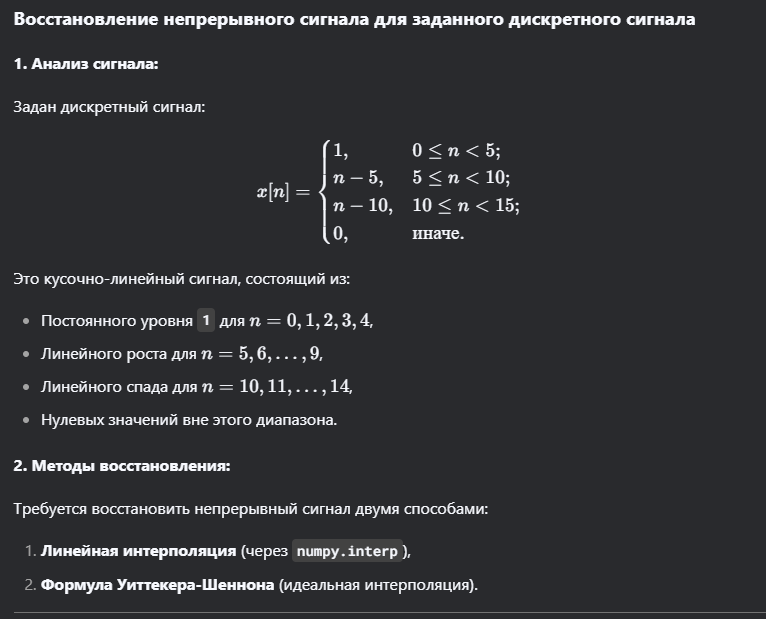

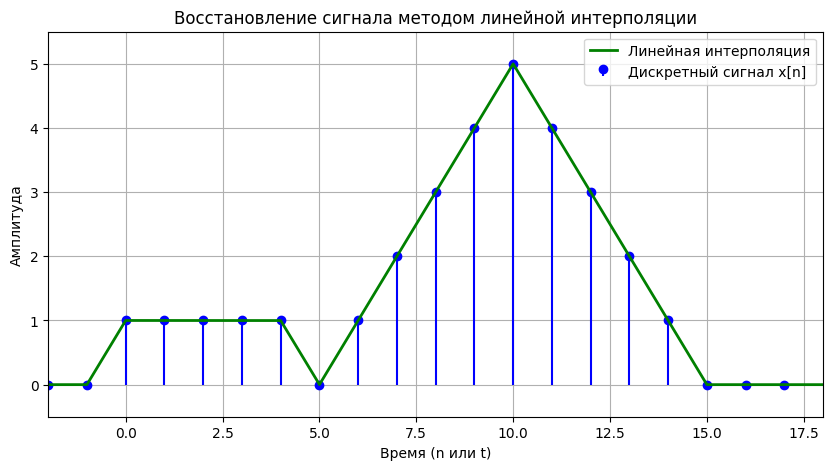

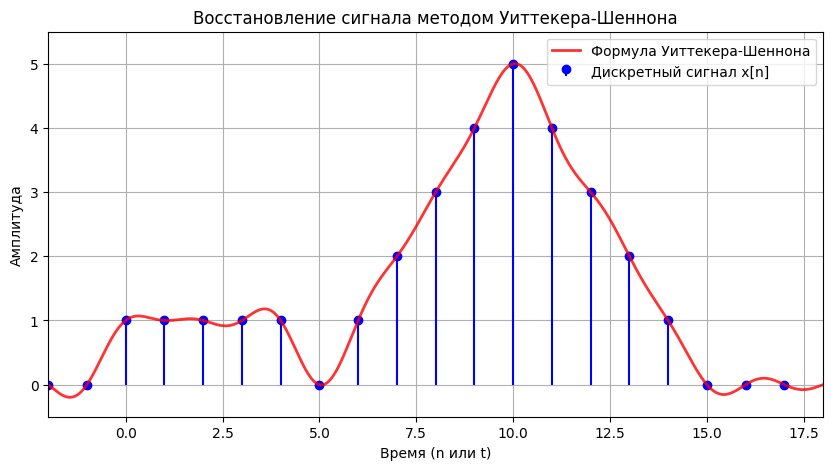

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Определение дискретного сигнала x[n]
def x_discrete(n):
    if 0 <= n < 5:
        return 1
    elif 5 <= n < 10:
        return n - 5
    elif 10 <= n < 15:
        return 15 - n  # Линейный спад
    else:
        return 0

# Дискретные отсчёты
n = np.arange(-2, 18)
x_n = np.array([x_discrete(i) for i in n])

# Мелкая сетка для "непрерывного" времени
t_continuous = np.linspace(-2, 18, 5000)

# Линейная интерполяция
x_linear = np.interp(t_continuous, n, x_n)

# График линейной интерполяции
plt.figure(figsize=(10, 5))
plt.stem(n, x_n, linefmt='b-', markerfmt='bo', basefmt=' ', label='Дискретный сигнал x[n]')
plt.plot(t_continuous, x_linear, 'g-', linewidth=2, label='Линейная интерполяция')
plt.xlabel('Время (n или t)')
plt.ylabel('Амплитуда')
plt.title('Восстановление сигнала методом линейной интерполяции')
plt.legend()
plt.grid(True)
plt.xlim(-2, 18)
plt.ylim(-0.5, 5.5)
plt.show()




# Восстановление через sinc-функции
x_sinc = np.zeros_like(t_continuous)
for i, t in enumerate(t_continuous):
    for k in n:
        if t - k != 0:
            x_sinc[i] += x_discrete(k) * np.sinc(t - k)
        else:
            x_sinc[i] += x_discrete(k)  # Учёт точки t = k

# График sinc-интерполяции
plt.figure(figsize=(10, 5))
plt.stem(n, x_n, linefmt='b-', markerfmt='bo', basefmt=' ', label='Дискретный сигнал x[n]')
plt.plot(t_continuous, x_sinc, 'r-', linewidth=2, label='Формула Уиттекера-Шеннона', alpha=0.8)
plt.xlabel('Время (n или t)')
plt.ylabel('Амплитуда')
plt.title('Восстановление сигнала методом Уиттекера-Шеннона')
plt.legend()
plt.grid(True)
plt.xlim(-2, 18)
plt.ylim(-0.5, 5.5)
plt.show()